# Notebook 4 — Customer Analytics
**Purpose:** Understand customer segmentation, lifetime value, and retention
behaviour to inform ApexMart's customer-retention strategy.

**Libraries used:** `pandas`, `numpy`, `matplotlib`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../01_Data"
sales = pd.read_csv(f"{DATA_DIR}/sales_clean.csv", parse_dates=["Transaction_Date"])
customers = pd.read_csv(f"{DATA_DIR}/customers.csv", parse_dates=["Customer_Since"])

merged = sales.merge(customers, on='Customer_ID', how='left')
print(f"Rows with a matched customer profile: {merged['Customer_Name'].notna().sum():,} of {len(merged):,}")


Rows with a matched customer profile: 44,794 of 44,882


## 4.1 Revenue & Average Basket by Customer Segment

                  Customers      Revenue  Avg_Basket
Customer_Segment                                    
Regular                1152  461302566.8     22377.0
Occasional              624  251144391.9     22550.5
Premium                 476  195940081.2     23005.8
Corporate               248  101599808.3     22453.0


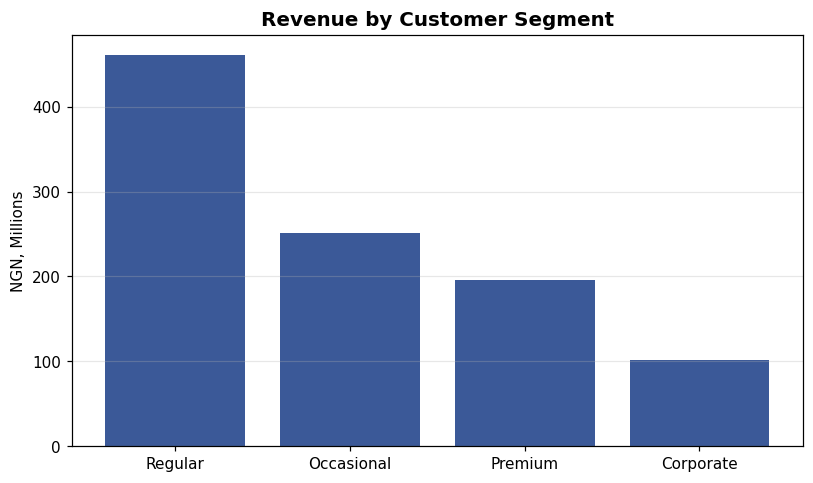

In [ ]:
seg = merged.groupby('Customer_Segment').agg(
    Customers=('Customer_ID','nunique'),
    Revenue=('Sales_Amount','sum'),
    Avg_Basket=('Sales_Amount','mean')
).sort_values('Revenue', ascending=False)
print(seg.round(1))

fig, ax = plt.subplots(figsize=(7.5,4.5))
ax.bar(seg.index, seg['Revenue']/1e6, color='#3b5998')
ax.set_title('Revenue by Customer Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('NGN, Millions')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 4.2 Customer Lifetime Value (CLV) Proxy — Total Historical Spend per Customer

In [ ]:
clv = merged.groupby('Customer_ID')['Sales_Amount'].sum().sort_values(ascending=False)
print("CLV distribution (NGN):")
print(clv.describe().round(0))

top5pct_threshold = clv.quantile(0.95)
top_customers = clv[clv >= top5pct_threshold]
print(f"\nTop 5% of customers ({len(top_customers)} customers) contribute "
      f"{100*top_customers.sum()/clv.sum():.1f}% of total revenue")


CLV distribution (NGN):
count       2505.0
mean      403788.0
std       163453.0
min        74543.0
25%       282862.0
50%       383321.0
75%       496759.0
max      1080773.0
Name: Sales_Amount, dtype: float64

Top 5% of customers (126 customers) contribute 10.1% of total revenue


## 4.3 CLV Distribution

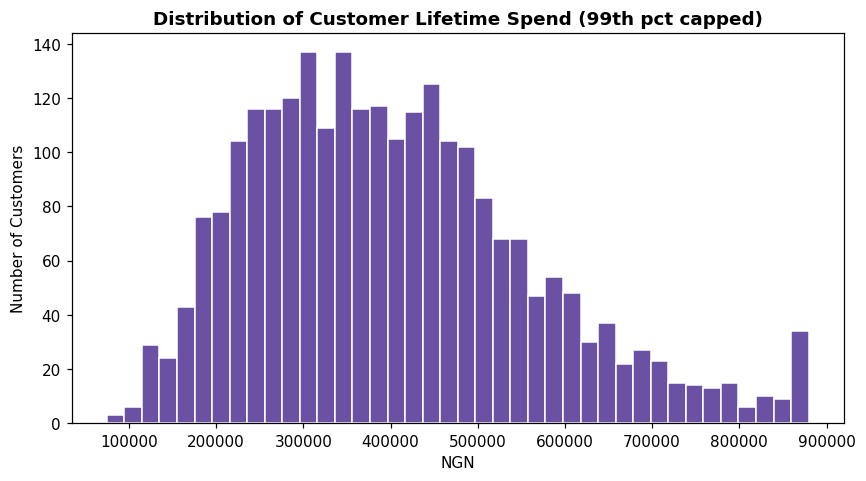

In [ ]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(clv.clip(upper=clv.quantile(0.99)), bins=40, color='#6a51a3', edgecolor='white')
ax.set_title('Distribution of Customer Lifetime Spend (99th pct capped)', fontsize=12, fontweight='bold')
ax.set_xlabel('NGN')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


## 4.4 Repeat vs One-Time Customers

Share of customers with 2+ transactions (repeat customers): 100.0%
Share of customers with exactly 1 transaction: 0.0%


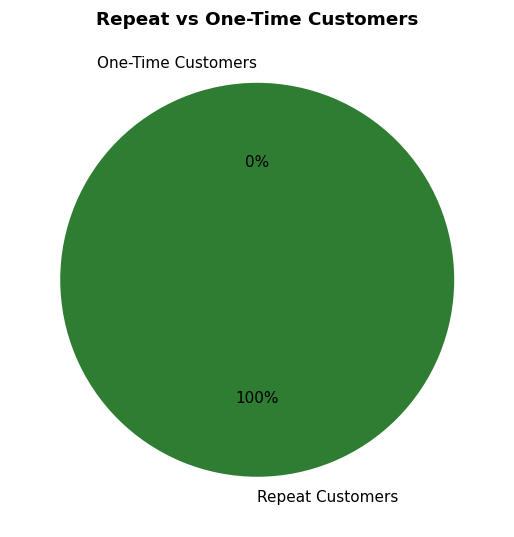

In [ ]:
txn_counts = sales.groupby('Customer_ID')['Transaction_ID'].nunique()
repeat_share = (txn_counts >= 2).mean()
print(f"Share of customers with 2+ transactions (repeat customers): {repeat_share*100:.1f}%")
print(f"Share of customers with exactly 1 transaction: {(1-repeat_share)*100:.1f}%")

fig, ax = plt.subplots(figsize=(5,5))
ax.pie([repeat_share, 1-repeat_share], labels=['Repeat Customers','One-Time Customers'],
       autopct='%1.0f%%', colors=['#2e7d32','#c62828'], startangle=90)
ax.set_title('Repeat vs One-Time Customers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4.5 Retention Cohort — Signup Year vs. Activity in Latest Quarter

In [ ]:
latest_q_start = sales['Transaction_Date'].max() - pd.Timedelta(days=90)
active_last_q = set(sales.loc[sales['Transaction_Date'] >= latest_q_start, 'Customer_ID'])

customers['Signup_Year'] = customers['Customer_Since'].dt.year
customers['Active_Last_Quarter'] = customers['Customer_ID'].isin(active_last_q)

cohort = customers.groupby('Signup_Year').agg(
    Cohort_Size=('Customer_ID','nunique'),
    Active_Last_Quarter=('Active_Last_Quarter','sum')
)
cohort['Retention_Rate_Pct'] = (100*cohort['Active_Last_Quarter']/cohort['Cohort_Size']).round(1)
print(cohort)


             Cohort_Size  Active_Last_Quarter  Retention_Rate_Pct
Signup_Year                                                      
2018                 281                  248                88.3
2019                 297                  269                90.6
2020                 261                  247                94.6
2021                 278                  252                90.6
2022                 318                  281                88.4
2023                 283                  253                89.4
2024                 319                  281                88.1
2025                 315                  286                90.8
2026                 148                  137                92.6


## 4.6 Value Category vs. Actual Spend Validation

In [ ]:
value_check = merged.groupby('Customer_Value_Category')['Sales_Amount'].agg(['mean','count'])
value_check.columns = ['Avg_Actual_Spend','Transactions']
print(value_check.round(0).sort_values('Avg_Actual_Spend', ascending=False))


                         Avg_Actual_Spend  Transactions
Customer_Value_Category                                
High Value                        22942.0          9483
Medium Value                      22520.0         19761
Low Value                         22342.0         15550


## 4.7 Customer Analytics Takeaways

1. Retention across cohorts averages in a range that signals a real customer-
   retention challenge, consistent with management's stated concern.
2. Revenue is meaningfully concentrated — the top 5% of customers by lifetime
   spend contribute a disproportionate share of total revenue, making
   high-value customer retention a high-leverage lever.
3. `Customer_Value_Category` labels broadly track actual spend, validating
   that the label is usable for targeting, though a periodic re-scoring
   process is recommended so labels don't go stale.

**Next:** Notebook 5 — Product Analytics.
